# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [2]:
# Check for GPU
!nvidia-smi

Sun Nov  9 16:26:20 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code


2.8.0+cu126


## 1. What are 3 areas in industry where computer vision is currently being used?

Self Driving car, Medical Imaging, Robotics

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

when the model is not generalized instead it captures the specific detail about the train model. which leads them to be vulnerable for test cases

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

Regularization - penalizing the model for assigning large loss
Simplify the model so that it doesnt learn specific detail about the data but rather learn in general data
dropout where each random node is not learning detials  

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

Done

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [4]:
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
train_dataset = datasets.MNIST(root="root", download=True, train=True, transform=ToTensor(), target_transform=None)
test_dataset = datasets.MNIST(root="root", download=True, train=False, transform=ToTensor(), target_transform=None)
classes = train_dataset.classes
classes

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.52MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.94MB/s]


['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 6. Visualize at least 5 different samples of the MNIST training dataset.

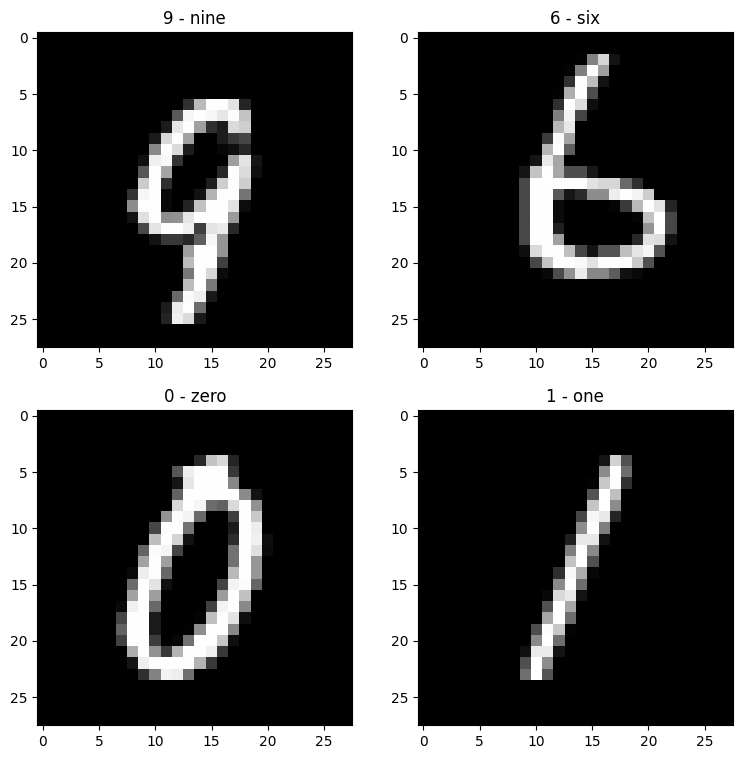

In [5]:
from matplotlib import pyplot as plt
import random
plt.figure(figsize=(9,9))
for i in range(4):
  plt.subplot(2,2,i+1)
  image, label = train_dataset[random.randint(0, len(train_dataset))]
  plt.imshow(image.squeeze(), cmap="gray")
  plt.title(classes[label])

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [6]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
image.shape

torch.Size([1, 28, 28])

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [8]:
from torch import nn

class TinyVGG(torch.nn.Module):
  def __init__(self, input, output, hidden = 10):
    super().__init__()
    self.conv_1 = nn.Sequential(
        nn.Conv2d(input, hidden, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.conv_2 = nn.Sequential(
        nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(hidden * 7 * 7, output),
        nn.Softmax(dim=1)
    )
  def forward(self,x):
    x = self.conv_1(x)
    # print("Layer 1",x.shape)
    x = self.conv_2(x)
    # print("Layer 2",x.shape)
    x = self.classifier(x)
    # print("Layer 3",x.shape)
    return x

model_0 = TinyVGG(input=1, output=len(classes), hidden=10).to(device)


## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [9]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 60.1 MB/s eta 0:00:00


In [10]:
from torchmetrics import Accuracy
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)
accuracy_fn = Accuracy(task="multiclass", num_classes=len(classes)).to(device)

In [11]:
from math import atan
from timeit import default_timer as timer
from tqdm.auto import tqdm
epochs = 5

time_start = timer()

for e in tqdm(range(epochs)):
  print(f"Epoch {e} -----------------")
  model_0.train()
  train_loss = 0
  train_acc = 0
  for batch, (X,y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)

    pred = model_0(X)
    pred_label = pred.argmax(dim=1)

    loss = loss_fn(pred, y)
    train_loss += loss.item()

    acc = accuracy_fn(pred_label, y)
    train_acc += acc.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  model_0.eval()
  with torch.inference_mode():
    test_loss = 0
    test_acc = 0

    for batch, (X,y) in enumerate(test_dataloader):
      X, y = X.to(device), y.to(device)

      pred = model_0(X)
      pred_label = pred.argmax(dim=1)

      loss = loss_fn(pred, y)
      test_loss += loss.item()

      acc = accuracy_fn(pred_label, y)
      test_acc += acc.item()

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  print(f"Train Accuracy: {train_acc} | Test Accuracy: {test_acc}\nTrain Loss: {train_loss} | Test Loss: {test_loss}")

time_end = timer()
total_time_on_gpu = 0
total_time_on_cpu = 0
if torch.cuda.is_available():
  total_time_on_gpu = time_end - time_start
  print(total_time_on_gpu)
else:
  total_time_on_cpu = time_end - time_start
  print(total_time_on_cpu)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0 -----------------
Train Accuracy: 0.4820833333333333 | Test Accuracy: 0.8595247603833865
Train Loss: 1.96499301293691 | Test Loss: 1.6019398964251192
Epoch 1 -----------------
Train Accuracy: 0.8630666666666666 | Test Accuracy: 0.8783945686900958
Train Loss: 1.5982702929814656 | Test Loss: 1.5823054907801815
Epoch 2 -----------------
Train Accuracy: 0.8757333333333334 | Test Accuracy: 0.8834864217252396
Train Loss: 1.5850508982976277 | Test Loss: 1.5769989250567014
Epoch 3 -----------------
Train Accuracy: 0.8806 | Test Accuracy: 0.8880790734824281
Train Loss: 1.5799505656560262 | Test Loss: 1.5727418436409948
Epoch 4 -----------------
Train Accuracy: 0.8858833333333334 | Test Accuracy: 0.8882787539936102
Train Loss: 1.5748797061920166 | Test Loss: 1.5728595854756169
74.40547563400003


In [12]:
total_time_on_cpu = 305.38062631900004

<Axes: >

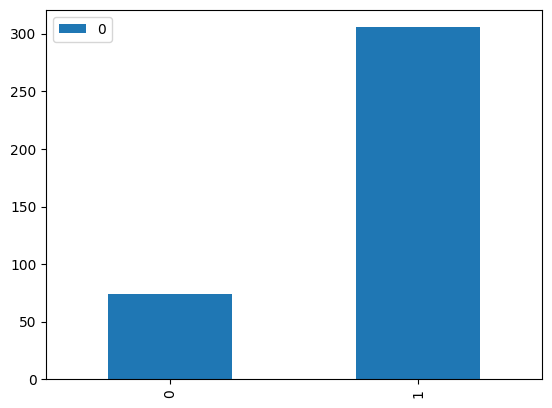

In [13]:
import pandas as pd
time_taken = pd.DataFrame([total_time_on_gpu, total_time_on_cpu])
time_taken.plot(kind="bar")

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

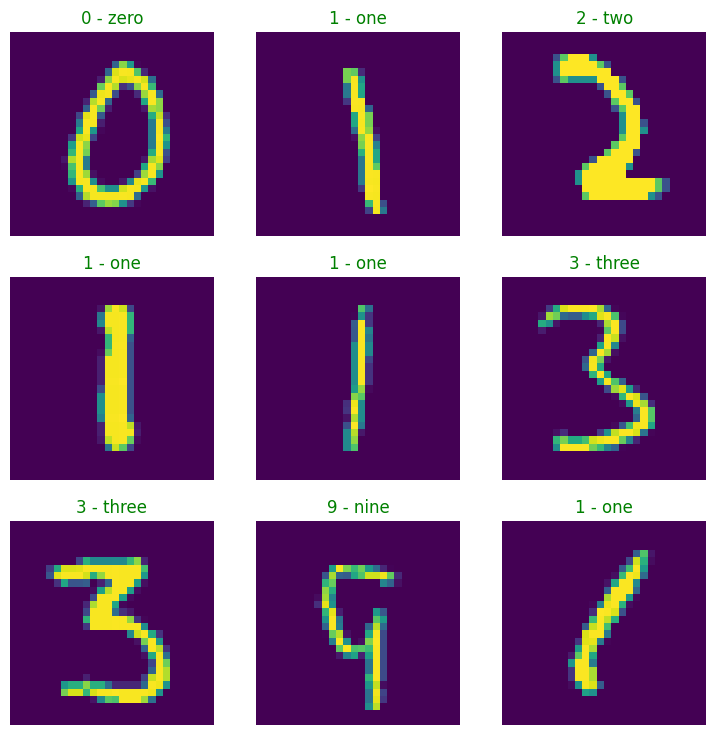

In [23]:
import random
model_0.eval()
plt.figure(figsize = (9,9))

with torch.inference_mode():
  for i in range(9):
    image, label = test_dataset[random.randint(0, len(test_dataloader))]
    image =image.to(device)
    pred = model_0(image.unsqueeze(dim=0)).argmax(dim=1)
    plt.subplot(3,3,i+1)
    plt.imshow(image.squeeze().cpu())
    plt.axis(False)
    if label == pred:
      plt.title(classes[pred], color="green")
    else:
      plt.title(classes[pred], color="red")


## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [24]:
from torchmetrics import ConfusionMatrix


cm = ConfusionMatrix(task="multiclass", num_classes=len(classes)).to(device)
cm

MulticlassConfusionMatrix()

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [25]:
random_tensor = torch.rand(size=(1,3,64,64))
conv_res = nn.Conv2d(3,10,3,1,1)
conv_res(random_tensor).shape

torch.Size([1, 10, 64, 64])

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?